# Import libraries

In [498]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [499]:
import matplotlib.dates

In [931]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

In [501]:
import datetime

In [502]:
import seaborn as sns

# Load data

In [503]:
data = pd.read_csv('C:/Users/piala/Documents/Github/regression_predict/Train.csv')
riders = pd.read_csv('C:/Users/piala/Documents/Github/regression_predict/Riders.csv')
test_data = pd.read_csv('C:/Users/piala/Documents/Github/regression_predict/Test.csv')

In [123]:
#data_merge = pd.read_csv('C:/Users/piala/Documents/Github/regression_predict/data_merge.csv')

# Merge deliveries and riders data

In [936]:
data_merge = pd.merge(data, riders, how='left', left_on=['Rider Id'], right_on=['Rider Id'])

# Encode independent categorical variables

In [799]:
#Make User Id column numeric
a = data_merge['User Id'].str.split('User_Id_', n=1, expand = True)
data_merge['User Id (num)'] = a[1]
data_merge['User Id (num)'] = pd.to_numeric(data_merge['User Id (num)'])

In [800]:
#Make Rider Id column numeric
a = data_merge['Rider Id'].str.split('Rider_Id_', n=1, expand = True)
data_merge['Rider Id (num)'] = a[1]
data_merge['Rider Id (num)'] = pd.to_numeric(data_merge['Rider Id (num)'])

In [801]:
#One hot encode 'Personal or Business' columns
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), ['Personal or Business'])], remainder='passthrough')
X = pd.DataFrame(ct.fit_transform(data_merge))
data_merge['Business'] = X[0]
data_merge['Personal'] = X[1]

In [802]:
#Remove unnecessary columns
#data_merge.pop('Order No')
data_merge.pop('Vehicle Type')
data_merge.pop('Precipitation in millimeters')
data_merge.pop('User Id')
data_merge.pop('Rider Id')
data_merge.pop('Personal or Business')

0        Business
1        Personal
2        Business
3        Business
4        Personal
           ...   
21196    Personal
21197    Business
21198    Business
21199    Personal
21200    Business
Name: Personal or Business, Length: 21201, dtype: object

# Dealing with time columns
1. Transform to timestamps
2. Calculate time intervals between all time columns. Aim is to get a numeric value that can be tested for collinearity, 
    may act as a calculated value for the model
3. Check for any negative values (eg. impossible for a confirmation to happen before an order is placed)

4. To be decided: are there other limitations on the time intervals to filter the dataset?

In [940]:
#Transform time columns into 24 hour format
data_merge['Placement - Time'] = pd.to_datetime(data_merge['Placement - Time'], format='%I:%M:%S %p')
data_merge['Confirmation - Time'] = pd.to_datetime(data_merge['Confirmation - Time'], format='%I:%M:%S %p')
data_merge['Arrival at Pickup - Time'] = pd.to_datetime(data_merge['Arrival at Pickup - Time'], format='%I:%M:%S %p')
data_merge['Pickup - Time'] = pd.to_datetime(data_merge['Pickup - Time'], format='%I:%M:%S %p')
data_merge['Arrival at Destination - Time'] = pd.to_datetime(data_merge['Arrival at Destination - Time'], format='%I:%M:%S %p')

In [944]:
#Calculate differences between all time columns
difference0 = (data_merge['Confirmation - Time'] - data_merge['Placement - Time']).astype('timedelta64[s]').astype(np.int64)
difference1 = (data_merge['Arrival at Pickup - Time'] - data_merge['Placement - Time']).astype('timedelta64[s]')
difference2 = (data_merge['Pickup - Time'] - data_merge['Placement - Time']).astype('timedelta64[s]')
difference3 = (data_merge['Arrival at Destination - Time'] - data_merge['Placement - Time']).astype('timedelta64[s]')
difference4 = (data_merge['Arrival at Pickup - Time'] - data_merge['Confirmation - Time']).astype('timedelta64[s]')
difference5 = (data_merge['Pickup - Time'] - data_merge['Confirmation - Time']).astype('timedelta64[s]')
difference6 = (data_merge['Arrival at Destination - Time'] - data_merge['Confirmation - Time']).astype('timedelta64[s]')
difference7 = (data_merge['Pickup - Time'] - data_merge['Arrival at Pickup - Time']).astype('timedelta64[s]')
difference8 = (data_merge['Arrival at Destination - Time'] - data_merge['Arrival at Pickup - Time']).astype('timedelta64[s]')
difference9 = (data_merge['Arrival at Destination - Time'] - data_merge['Pickup - Time']).astype('timedelta64[s]')

In [945]:
#Change intervals to integers for plotting
difference0 = difference0.astype(np.int64)
difference1 = difference1.astype(np.int64)
difference2 = difference2.astype(np.int64)
difference3 = difference3.astype(np.int64)
difference4 = difference4.astype(np.int64)
difference5 = difference5.astype(np.int64)
difference6 = difference6.astype(np.int64)
difference7 = difference7.astype(np.int64)
difference8 = difference8.astype(np.int64)
difference9 = difference9.astype(np.int64)

In [946]:
#Add time difference columns to data_merge for EDA and visualisations
data_merge['Con - Pl'] = difference0
data_merge['Arr P - Pl'] = difference1
data_merge['P - Pl'] = difference2
data_merge['Dest - Pl'] = difference3
data_merge['Arr P - Con'] = difference4
data_merge['P - Con'] = difference5
data_merge['Dest - Con'] = difference6
data_merge['P - Arr P'] = difference7
data_merge['Dest - Arr P'] = difference8
data_merge['Dest - P'] = difference9

In [823]:
data_merge = data_merge.set_index('Order No')

In [947]:
print(sum(data_merge['Con - Pl'] < 0))
print(sum(data_merge['Arr P - Pl'] < 0))
print(sum(data_merge['P - Pl'] < 0))
print(sum(data_merge['Dest - Pl'] < 0))
print(sum(data_merge['Arr P - Con'] < 0))
print(sum(data_merge['P - Con'] < 0))
print(sum(data_merge['Dest - Con'] < 0))
print(sum(data_merge['P - Arr P'] < 0))
print(sum(data_merge['Dest - Arr P'] < 0))
print(sum(data_merge['Dest - P'] < 0))
print(sum(data_merge['Time from Pickup to Arrival'] < 0))

6
2
1
0
0
0
0
0
0
0
0


In [948]:
ls = ['Con - Pl', 'Arr P - Pl', 'P - Pl', 'Dest - Pl', 'Arr P - Con', 'P - Con', 'Dest - Con', 'P - Arr P', 'Dest - Arr P', 'Dest - P', 'Time from Pickup to Arrival']
for i in range(len(ls)):
    data_merge = data_merge.drop(data_merge[data_merge[ls[i]] < 0].index)
print(len(data_merge)) #6 rows dropped

21195


In [949]:
#Drop rows that has negative time intervals (eg. not possible for the confirmation to happen before the order is placed)
data_merge = data_merge.drop(data_merge[data_merge['Con - Pl'] < 0].index)
print(len(data_merge)) #6 rows dropped

#Double check other time columns
print(sum(data_merge['Con - Pl'] < 0))
print(sum(data_merge['Arr P - Pl'] < 0))
print(sum(data_merge['P - Pl'] < 0))
print(sum(data_merge['Dest - Pl'] < 0))
print(sum(data_merge['Arr P - Con'] < 0))
print(sum(data_merge['P - Con'] < 0))
print(sum(data_merge['Dest - Con'] < 0))
print(sum(data_merge['P - Arr P'] < 0))
print(sum(data_merge['Dest - Arr P'] < 0))
print(sum(data_merge['Dest - P'] < 0))
print(sum(data_merge['Time from Pickup to Arrival'] < 0))

##Arrival, pickup, destination

21195
0
0
0
0
0
0
0
0
0
0
0


In [134]:
#Change datetime columns to timestamps
#data_merge['Placement - Time'] = pd.Series([val.time() for val in data_merge['Placement - Time']])
#data_merge['Confirmation - Time'] = pd.Series([val.time() for val in data_merge['Confirmation - Time']])
#data_merge['Arrival at Pickup - Time'] = pd.Series([val.time() for val in data_merge['Arrival at Pickup - Time']])
#data_merge['Pickup - Time'] = pd.Series([val.time() for val in data_merge['Pickup - Time']])
#data_merge['Arrival at Destination - Time'] = pd.Series([val.time() for val in data_merge['Arrival at Destination - Time']])

In [810]:
data_merge.head()

#For each time column have three extra columns for H, mins, sec

,Order No,Platform Type,Placement - Day of Month,Placement - Weekday (Mo = 1),Placement - Time,Confirmation - Day of Month,Confirmation - Weekday (Mo = 1),Confirmation - Time,Arrival at Pickup - Day of Month,Arrival at Pickup - Weekday (Mo = 1),...,Con - Pl,Arr P - Pl,P - Pl,Dest - Pl,Arr P - Con,P - Con,Dest - Con,P - Arr P,Dest - Arr P,Dest - P
0,Order_No_4211,3,9,5,1900-01-01 09:35:46,9,5,1900-01-01 09:40:10,9,5,...,264,1741,3104,3849,1477,2840,3585,1363,2108,745
1,Order_No_25375,3,12,5,1900-01-01 11:16:16,12,5,1900-01-01 11:23:21,12,5,...,425,1446,1673,3666,1021,1248,3241,227,2220,1993
2,Order_No_1899,3,30,2,1900-01-01 12:39:25,30,2,1900-01-01 12:42:44,30,2,...,199,609,818,1273,410,619,1074,209,664,455
3,Order_No_9336,3,15,5,1900-01-01 09:25:34,15,5,1900-01-01 09:26:05,15,5,...,31,742,1052,2393,711,1021,2362,310,1651,1341
4,Order_No_27883,1,13,1,1900-01-01 09:55:18,13,1,1900-01-01 09:56:18,13,1,...,60,515,605,1819,455,545,1759,90,1304,1214


# Transforming hours, mins and sec
1. Fourier transformation

In [871]:
time_vars = data_merge.loc[:, ['Placement - Time', 'Confirmation - Time', 'Arrival at Pickup - Time', 'Pickup - Time', 'Arrival at Destination - Time']]

#Calculate time in seconds from midnight
time_vars['pl'] = time_vars['Placement - Time']. apply(lambda x: (x - pd.to_datetime('12:00:00 AM', format='%I:%M:%S %p')).total_seconds())
time_vars['con'] = time_vars['Confirmation - Time']. apply(lambda x: (x - pd.to_datetime('12:00:00 AM', format='%I:%M:%S %p')).total_seconds())
time_vars['arr p'] = time_vars['Arrival at Pickup - Time']. apply(lambda x: (x - pd.to_datetime('12:00:00 AM', format='%I:%M:%S %p')).total_seconds())
time_vars['p'] = time_vars['Pickup - Time']. apply(lambda x: (x - pd.to_datetime('12:00:00 AM', format='%I:%M:%S %p')).total_seconds())
time_vars['dest'] = time_vars['Arrival at Destination - Time']. apply(lambda x: (x - pd.to_datetime('12:00:00 AM', format='%I:%M:%S %p')).total_seconds())

time_vars['pl_sin'] = time_vars['pl'].apply(lambda x: np.sin(x*(2.*np.pi/86400)))
time_vars['pl_cos'] = time_vars['pl'].apply(lambda x: np.cos(x*(2.*np.pi/86400)))

time_vars['con_sin'] = time_vars['con'].apply(lambda x: np.sin(x*(2.*np.pi/86400)))
time_vars['con_cos'] = time_vars['con'].apply(lambda x: np.cos(x*(2.*np.pi/86400)))

time_vars['arr p_sin'] = time_vars['arr p'].apply(lambda x: np.sin(x*(2.*np.pi/86400)))
time_vars['arr p_cos'] = time_vars['arr p'].apply(lambda x: np.cos(x*(2.*np.pi/86400)))

time_vars['p_sin'] = time_vars['p'].apply(lambda x: np.sin(x*(2.*np.pi/86400)))
time_vars['p_cos'] = time_vars['p'].apply(lambda x: np.cos(x*(2.*np.pi/86400)))

time_vars['dest_sin'] = time_vars['dest'].apply(lambda x: np.sin(x*(2.*np.pi/86400)))
time_vars['dest_cos'] = time_vars['dest'].apply(lambda x: np.cos(x*(2.*np.pi/86400)))
time_vars.head()

,Placement - Time,Confirmation - Time,Arrival at Pickup - Time,Pickup - Time,Arrival at Destination - Time,pl,con,arr p,p,dest,pl_sin,pl_cos,con_sin,con_cos,arr p_sin,arr p_cos,p_sin,p_cos,dest_sin,dest_cos
Order No,,,,,,,,,,,,,,,,,,,,
Order_No_4211,1900-01-01 09:35:46,1900-01-01 09:40:10,1900-01-01 10:04:47,1900-01-01 10:27:30,1900-01-01 10:39:55,34546.0,34810.0,36287.0,37650.0,38395.0,0.588609,-0.808418,0.572981,-0.819569,0.481817,-0.876272,0.392738,-0.919650,0.342362,-0.939568
Order_No_25375,1900-01-01 11:16:16,1900-01-01 11:23:21,1900-01-01 11:40:22,1900-01-01 11:44:09,1900-01-01 12:17:22,40576.0,41001.0,42022.0,42249.0,44242.0,0.189667,-0.981849,0.159235,-0.987241,0.085562,-0.996333,0.069104,-0.997609,-0.075704,-0.997130
Order_No_1899,1900-01-01 12:39:25,1900-01-01 12:42:44,1900-01-01 12:49:34,1900-01-01 12:53:03,1900-01-01 13:00:38,45565.0,45764.0,46174.0,46383.0,46838.0,-0.171141,-0.985247,-0.185381,-0.982667,-0.214593,-0.976703,-0.229413,-0.973329,-0.261487,-0.965207
Order_No_9336,1900-01-01 09:25:34,1900-01-01 09:26:05,1900-01-01 09:37:56,1900-01-01 09:43:06,1900-01-01 10:05:27,33934.0,33965.0,34676.0,34986.0,36327.0,0.623993,-0.781430,0.622230,-0.782834,0.580940,-0.813947,0.562444,-0.826835,0.479266,-0.877669
Order_No_27883,1900-01-01 09:55:18,1900-01-01 09:56:18,1900-01-01 10:03:53,1900-01-01 10:05:23,1900-01-01 10:25:37,35718.0,35778.0,36233.0,36323.0,37537.0,0.517654,-0.855590,0.513916,-0.857841,0.485255,-0.874373,0.479522,-0.877530,0.400282,-0.916392


In [907]:
#Add data to primary dataset
data_merge['pl_sin'] = time_vars['pl_sin']
data_merge['pl_cos'] = time_vars['pl_cos']

data_merge['con_sin'] = time_vars['con_sin']
data_merge['con_cos'] = time_vars['con_cos']

data_merge['arr p_sin'] = time_vars['arr p_sin']
data_merge['arr p_cos'] = time_vars['arr p_cos']

data_merge['p_sin'] = time_vars['p_sin']
data_merge['p_cos'] = time_vars['p_cos']

data_merge['arr p_sin'] = time_vars['dest']
data_merge['dest_cos'] = time_vars['dest_cos']

In [908]:
#Remove unnecessary columns
data_merge.pop('Placement - Time')
data_merge.pop('Confirmation - Time')
data_merge.pop('Arrival at Pickup - Time')
data_merge.pop('Pickup - Time')
data_merge.pop('Arrival at Destination - Time')

Order No
Order_No_4211    1900-01-01 10:39:55
Order_No_25375   1900-01-01 12:17:22
Order_No_1899    1900-01-01 13:00:38
Order_No_9336    1900-01-01 10:05:27
Order_No_27883   1900-01-01 10:25:37
                         ...        
Order_No_9932    1900-01-01 14:33:21
Order_No_22892   1900-01-01 10:46:17
Order_No_2831    1900-01-01 18:40:05
Order_No_6174    1900-01-01 10:08:15
Order_No_9836    1900-01-01 15:17:23
Name: Arrival at Destination - Time, Length: 20301, dtype: datetime64[ns]

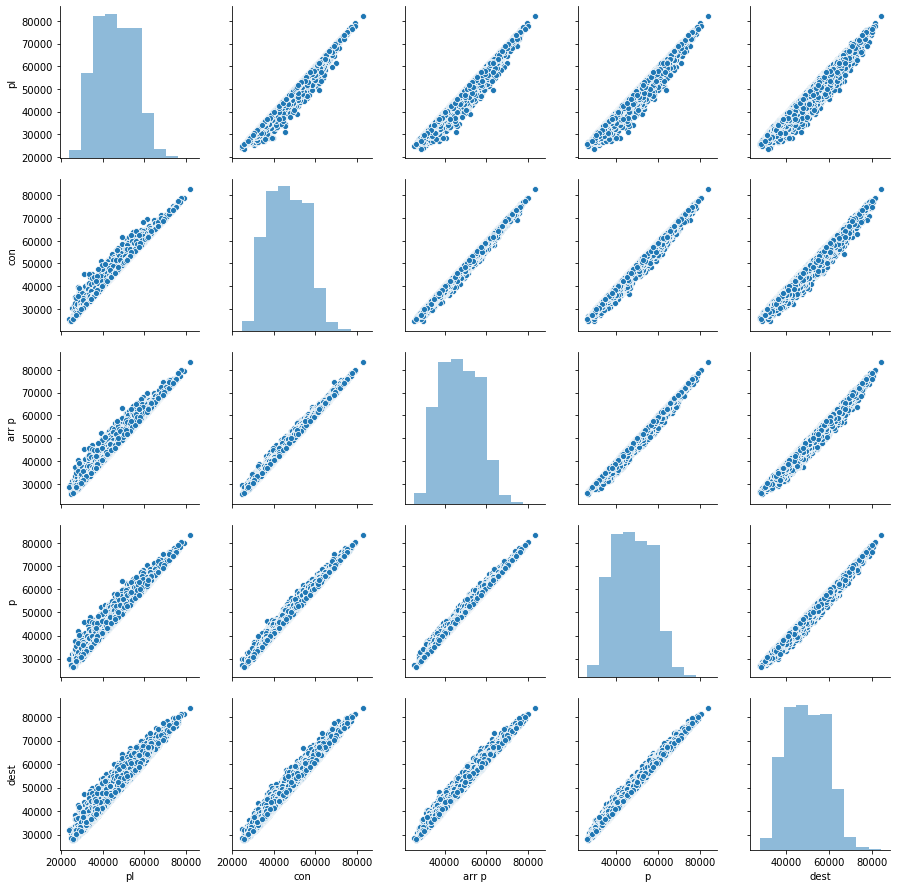

<Figure size 432x288 with 0 Axes>

In [869]:
sns.pairplot(data=time_vars,
        vars=['pl', 'con', 'arr p', 'p', 'dest'],
        kind='scatter',
        palette='RdBu',
        diag_kws={'alpha':.5})

plt.show()
plt.clf()

In [850]:
#sin/cos transform day of the week
day = data_merge.loc[:, ['Arrival at Destination - Weekday (Mo = 1)']]
day['day_sin'] = day['Arrival at Destination - Weekday (Mo = 1)'].apply(lambda x: np.sin(x*(2.*np.pi/7)))
day['day_cos'] = day['Arrival at Destination - Weekday (Mo = 1)'].apply(lambda x: np.cos(x*(2.*np.pi/7)))
day.head()

,Arrival at Destination - Weekday (Mo = 1),day_sin,day_cos
Order No,,,
Order_No_4211,5,-0.974928,-0.222521
Order_No_25375,5,-0.974928,-0.222521
Order_No_1899,2,0.974928,-0.222521
Order_No_9336,5,-0.974928,-0.222521
Order_No_27883,1,0.781831,0.623490


In [910]:
#Add data to primary dataset
data_merge['weekday_sin'] = day['day_sin']
data_merge['weekday_cos'] = day['day_cos']

In [911]:
#Remove unnecessary columns
data_merge.pop('Arrival at Destination - Weekday (Mo = 1)')

Order No
Order_No_4211     5
Order_No_25375    5
Order_No_1899     2
Order_No_9336     5
Order_No_27883    1
                 ..
Order_No_9932     6
Order_No_22892    6
Order_No_2831     4
Order_No_6174     3
Order_No_9836     2
Name: Arrival at Destination - Weekday (Mo = 1), Length: 20301, dtype: int64

In [849]:
#sin/cos transform day of the month
day_month = data_merge.loc[:, ['Arrival at Destination - Day of Month']]
day_month['day_sin'] = day_month['Arrival at Destination - Day of Month']. apply(lambda x: np.sin(x*(2.*np.pi/31)))
day_month['day_cos'] = day_month['Arrival at Destination - Day of Month']. apply(lambda x: np.cos(x*(2.*np.pi/31)))
day_month.head()

,Arrival at Destination - Day of Month,day_sin,day_cos
Order No,,,
Order_No_4211,9,0.968077,-0.250653
Order_No_25375,12,0.651372,-0.758758
Order_No_1899,30,-0.201299,0.979530
Order_No_9336,15,0.101168,-0.994869
Order_No_27883,13,0.485302,-0.874347


In [912]:
#Add data to primary dataset
data_merge['day_month_sin'] = day_month['day_sin']
data_merge['day_month_cos'] = day_month['day_cos']

In [913]:
#Remove unnecessary columns
data_merge.pop('Arrival at Destination - Day of Month')

Order No
Order_No_4211      9
Order_No_25375    12
Order_No_1899     30
Order_No_9336     15
Order_No_27883    13
                  ..
Order_No_9932      2
Order_No_22892    13
Order_No_2831      7
Order_No_6174      4
Order_No_9836     26
Name: Arrival at Destination - Day of Month, Length: 20301, dtype: int64

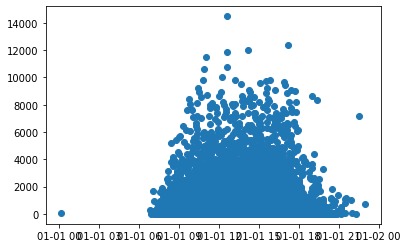

In [811]:
dates = matplotlib.dates.date2num(data_merge['Confirmation - Time'])
matplotlib.pyplot.plot_date(dates, data_merge['Con - Pl'])

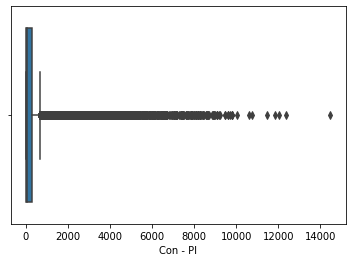

In [812]:
sns.boxplot(x=data_merge['Con - Pl'])

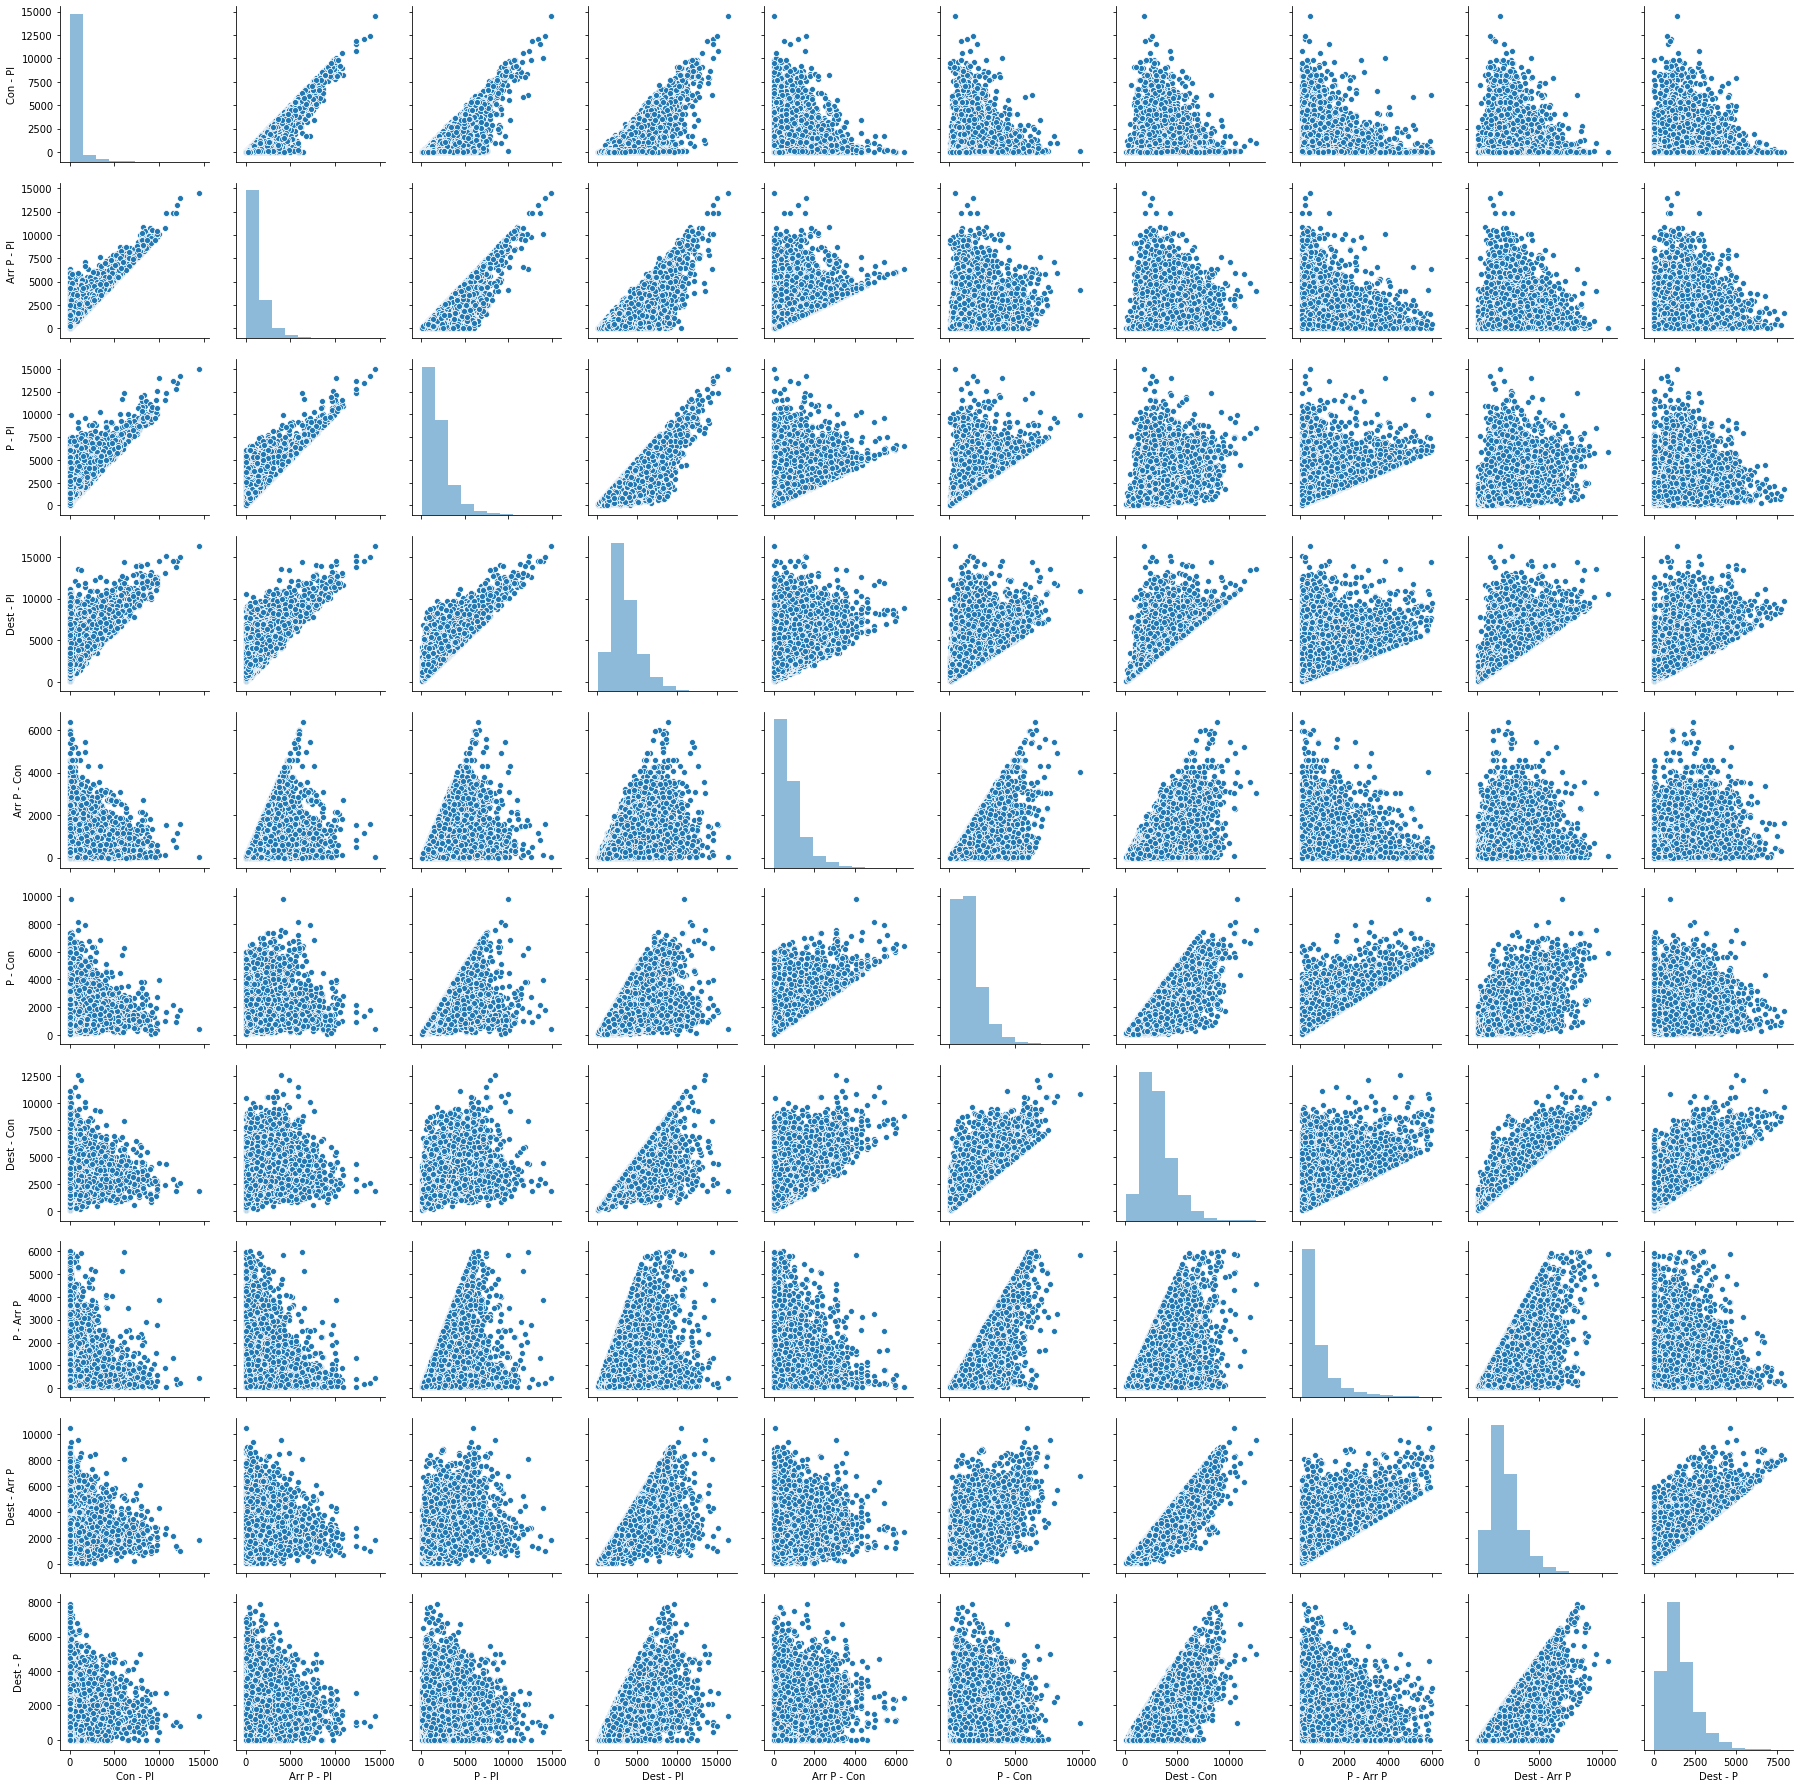

<Figure size 432x288 with 0 Axes>

In [813]:
sns.pairplot(data=data_merge,
        vars=['Con - Pl', 'Arr P - Pl', 'P - Pl', 'Dest - Pl', 'Arr P - Con', 'P - Con', 'Dest - Con', 'P - Arr P', 'Dest - Arr P', 'Dest - P'],
        kind='scatter',
        palette='RdBu',
        diag_kws={'alpha':.5})

plt.show()
plt.clf()

In [916]:
#Move dependent variable to the end
data_merge['Time from Pickup to Arrival'] = data_merge.pop('Time from Pickup to Arrival')

In [917]:
data_merge.to_csv('data_merge.csv')

# Dealing with latitude and longitude columns
1. Convert to geohash values, these can then be encoded (Geohash package)
2. Troubleshoot accuracy parameter, need to reverse transform as well to ensure that the same coordinates are returned.
3. Consider UTM transformation (may not be the most accurate because works best with elevation value, small error margin though)

In [ ]:
# %load 'C:/Users/piala/Anaconda3/Lib/site-packages/Geohash/Geohash.py'
C:/Users/piala/Anaconda3/Lib/site-packages/Geohash/Geohash.py

In [883]:
%run -i C:/Users/piala/Anaconda3/Lib/site-packages/Geohash/Geohash.py

In [891]:
# %load Geohash.py
"""
Copyright (C) 2008 Leonard Norrgard <leonard.norrgard@gmail.com>
Copyright (C) 2015 Leonard Norrgard <leonard.norrgard@gmail.com>

This file is part of Geohash.

Geohash is free software: you can redistribute it and/or modify it
under the terms of the GNU Affero General Public License as published
by the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

Geohash is distributed in the hope that it will be useful, but WITHOUT
ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or
FITNESS FOR A PARTICULAR PURPOSE.  See the GNU Affero General Public
License for more details.

You should have received a copy of the GNU Affero General Public
License along with Geohash.  If not, see
<http://www.gnu.org/licenses/>.
"""
from math import log10

#  Note: the alphabet in geohash differs from the common base32
#  alphabet described in IETF's RFC 4648
#  (http://tools.ietf.org/html/rfc4648)
__base32 = '0123456789bcdefghjkmnpqrstuvwxyz'
__decodemap = { }
for i in range(len(__base32)):
    __decodemap[__base32[i]] = i
del i

def decode_exactly(geohash):
    """
    Decode the geohash to its exact values, including the error
    margins of the result.  Returns four float values: latitude,
    longitude, the plus/minus error for latitude (as a positive
    number) and the plus/minus error for longitude (as a positive
    number).
    """
    lat_interval, lon_interval = (-90.0, 90.0), (-180.0, 180.0)
    lat_err, lon_err = 90.0, 180.0
    is_even = True
    for c in geohash:
        cd = __decodemap[c]
        for mask in [16, 8, 4, 2, 1]:
            if is_even: # adds longitude info
                lon_err /= 2
                if cd & mask:
                    lon_interval = ((lon_interval[0]+lon_interval[1])/2, lon_interval[1])
                else:
                    lon_interval = (lon_interval[0], (lon_interval[0]+lon_interval[1])/2)
            else:      # adds latitude info
                lat_err /= 2
                if cd & mask:
                    lat_interval = ((lat_interval[0]+lat_interval[1])/2, lat_interval[1])
                else:
                    lat_interval = (lat_interval[0], (lat_interval[0]+lat_interval[1])/2)
            is_even = not is_even
    lat = (lat_interval[0] + lat_interval[1]) / 2
    lon = (lon_interval[0] + lon_interval[1]) / 2
    return lat, lon, lat_err, lon_err

def decode(geohash):
    """
    Decode geohash, returning two strings with latitude and longitude
    containing only relevant digits and with trailing zeroes removed.
    """
    lat, lon, lat_err, lon_err = decode_exactly(geohash)
    # Format to the number of decimals that are known
    lats = "%.*f" % (max(1, int(round(-log10(lat_err)))) - 1, lat)
    lons = "%.*f" % (max(1, int(round(-log10(lon_err)))) - 1, lon)
    if '.' in lats: lats = lats.rstrip('0')
    if '.' in lons: lons = lons.rstrip('0')
    return lats, lons

def encode(latitude, longitude, precision=12):
    """
    Encode a position given in float arguments latitude, longitude to
    a geohash which will have the character count precision.
    """
    lat_interval, lon_interval = (-90.0, 90.0), (-180.0, 180.0)
    geohash = []
    bits = [ 16, 8, 4, 2, 1 ]
    bit = 0
    ch = 0
    even = True
    while len(geohash) < precision:
        if even:
            mid = (lon_interval[0] + lon_interval[1]) / 2
            if longitude > mid:
                ch |= bits[bit]
                lon_interval = (mid, lon_interval[1])
            else:
                lon_interval = (lon_interval[0], mid)
        else:
            mid = (lat_interval[0] + lat_interval[1]) / 2
            if latitude > mid:
                ch |= bits[bit]
                lat_interval = (mid, lat_interval[1])
            else:
                lat_interval = (lat_interval[0], mid)
        even = not even
        if bit < 4:
            bit += 1
        else:
            geohash += __base32[ch]
            bit = 0
            ch = 0
    return ''.join(geohash)


In [898]:
encode(42.6, -5.6, precision=7)

'ezs42e4'

In [919]:
geohash = data_merge.loc[:, ['Pickup Lat', 'Pickup Long', 'Destination Lat', 'Destination Long']]
geohash.head()

KeyError: "None of [Index(['Pickup Lat', 'Pickup Long', 'Destination Lat', 'Destination Long'], dtype='object')] are in the [columns]"

In [905]:
geohash['pickup'] = 0
geohash['dest'] = 0
for i in range(len(geohash)):
    geohash.iloc[i, 4] = encode(geohash.iloc[i, 0], geohash.iloc[i, 1], precision=6)
    geohash.iloc[i, 5] = encode(geohash.iloc[i, 2], geohash.iloc[i, 3], precision=6)
geohash.head()

,Pickup Lat,Pickup Long,Destination Lat,Destination Long,pickup,dest
Order No,,,,,,
Order_No_4211,-1.317755,36.830370,-1.300406,36.829741,kzf0w0,kzf0w5
Order_No_25375,-1.351453,36.899315,-1.295004,36.814358,kzf0r9,kzf0ts
Order_No_1899,-1.308284,36.843419,-1.300921,36.828195,kzf0w3,kzf0w5
Order_No_9336,-1.281301,36.832396,-1.257147,36.795063,kzf0wn,kzf0v7
Order_No_27883,-1.266597,36.792118,-1.295041,36.809817,kzf0v1,kzf0ts


In [906]:
print(len(set(geohash['pickup'])))
print(len(set(geohash['dest'])))

515
701


In [914]:
#Add data to primary dataset
data_merge['pickup_geohash'] = geohash['pickup']
data_merge['dest_geohash'] = geohash['dest']

In [915]:
#Remove unnecessary columns
data_merge.pop('Pickup Lat')
data_merge.pop('Pickup Long')
data_merge.pop('Destination Lat')
data_merge.pop('Destination Long')

Order No
Order_No_4211     36.829741
Order_No_25375    36.814358
Order_No_1899     36.828195
Order_No_9336     36.795063
Order_No_27883    36.809817
                    ...    
Order_No_9932     36.766981
Order_No_22892    36.847976
Order_No_2831     36.804800
Order_No_6174     36.794872
Order_No_9836     36.830887
Name: Destination Long, Length: 20301, dtype: float64

In [934]:
# label_encoder object knows how to understand word labels. 
label_encoder = LabelEncoder()
# Encode labels in column 'Country'. 
data_merge['pickup_geohash']= label_encoder.fit_transform(data_merge['pickup_geohash'])
data_merge['dest_geohash']= label_encoder.fit_transform(data_merge['dest_geohash'])

# Drivers
1. Ranking by ratings
2. Efficiency

In [922]:
riders_adj = data_merge.loc[:, ['No_Of_Orders', 'Age', 'Average_Rating', 'No_of_Ratings']]
riders_adj.head()

,No_Of_Orders,Age,Average_Rating,No_of_Ratings
Order No,,,,
Order_No_4211,1637,1309,13.8,549
Order_No_25375,396,339,13.6,69
Order_No_1899,1023,242,12.5,114
Order_No_9336,886,283,14.5,113
Order_No_27883,2311,872,14.1,533


In [926]:
total = sum(riders_adj['No_of_Ratings'])
riders_adj['ranking'] = 0
riders_adj['rate_of_deliveries'] = 0
for i in range(len(riders_adj)):
    riders_adj.iloc[i, 4] = riders_adj.iloc[i, 2] * (riders_adj.iloc[i, 3] / total)
    riders_adj.iloc[i, 5] = riders_adj.iloc[i, 0] / riders_adj.iloc[i, 1]
riders_adj.head()

,No_Of_Orders,Age,Average_Rating,No_of_Ratings,ranking,rate_of_deliveries
Order No,,,,,,
Order_No_4211,1637,1309,13.8,549,0.001096,1.250573
Order_No_25375,396,339,13.6,69,0.000136,1.168142
Order_No_1899,1023,242,12.5,114,0.000206,4.227273
Order_No_9336,886,283,14.5,113,0.000237,3.130742
Order_No_27883,2311,872,14.1,533,0.001087,2.650229


In [927]:
#Add data to primary dataset
data_merge['rider_ranking'] = riders_adj['ranking']
data_merge['rate_of_deliveries'] = riders_adj['rate_of_deliveries']

In [928]:
#Remove unnecessary columns
data_merge.pop('No_Of_Orders')
data_merge.pop('Age')
data_merge.pop('Average_Rating')
data_merge.pop('No_of_Ratings')

Order No
Order_No_4211      549
Order_No_25375      69
Order_No_1899      114
Order_No_9336      113
Order_No_27883     533
                  ... 
Order_No_9932        5
Order_No_22892     114
Order_No_2831       29
Order_No_6174     1101
Order_No_9836       70
Name: No_of_Ratings, Length: 20301, dtype: int64

# Temperature
1. For missing values, calculate mean temperature values per hour

In [950]:
temp_adj = data_merge.loc[:, ['Temperature', 'Placement - Time']]
temp_adj['hour'] = temp_adj['Placement - Time'].apply(lambda x: x.hour)
mean_temps = mean_temps.drop(mean_temps[mean_temps['Temperature'].isna()].index)
mean_temps = mean_temps.groupby(['hour'], as_index=False).mean()
mean_temps

,hour,Temperature
0,0,18.600000
1,6,16.437500
2,7,18.580153
3,8,18.685175
4,9,19.242606
5,10,22.557205
6,11,23.323023
7,12,23.515638
8,13,24.898096
9,14,25.366790


In [815]:
#Replace nan Temperatures with mean per hour
a = temp_adj['Temperature'].isna()

for i in range(len(a)):
    if a.iloc[i] == True:
        temp_adj.iloc[i, 0] = mean_temps.loc[mean_temps['hour'] == temp_adj.iloc[i, 2], 'Temperature'].values[0]

data_merge['temp_adj'] = temp_adj['Temperature']
data_merge['temp_adj'].head(10)
print(sum(data_merge['temp_adj'].isna()))

#Remove old Temperature column
data_merge.pop('Temperature')

0


0        20.4
1        26.4
2         NaN
3        19.2
4        15.4
         ... 
21196    28.6
21197    26.0
21198    29.2
21199    15.0
21200    30.9
Name: Temperature, Length: 21195, dtype: float64

# EDA

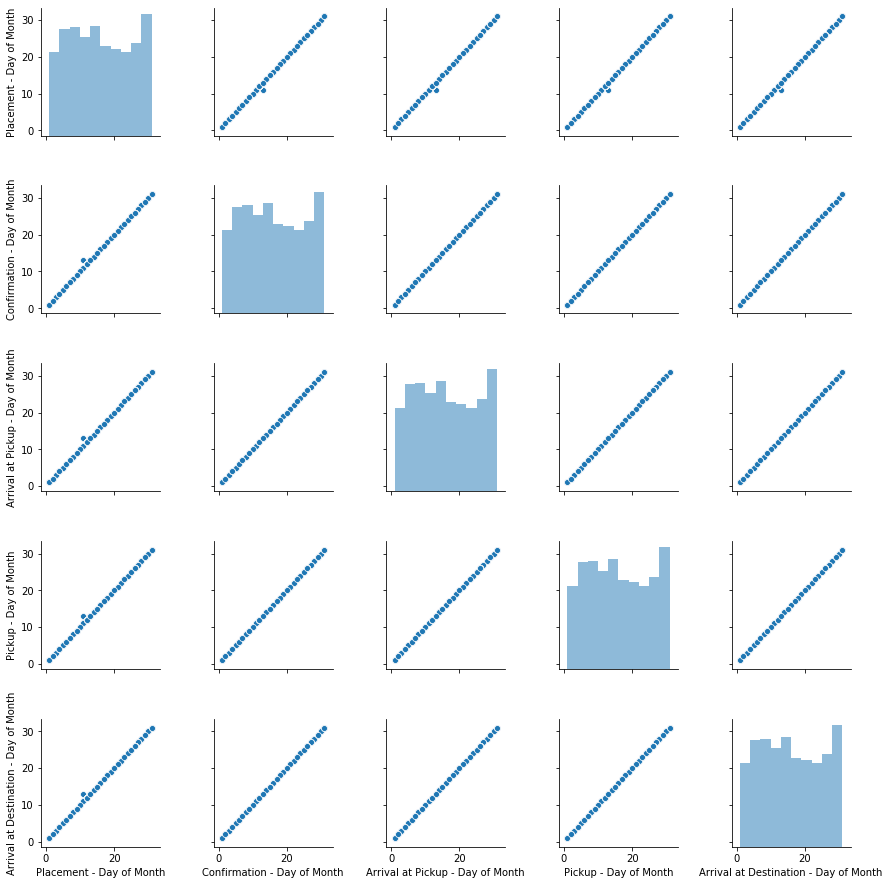

<Figure size 432x288 with 0 Axes>

In [817]:
sns.pairplot(data=data_merge,
        vars=['Placement - Day of Month', 'Confirmation - Day of Month', 'Arrival at Pickup - Day of Month', 'Pickup - Day of Month', 'Arrival at Destination - Day of Month'],
        kind='scatter',
        palette='RdBu',
        diag_kws={'alpha':.5})

plt.show()
plt.clf()

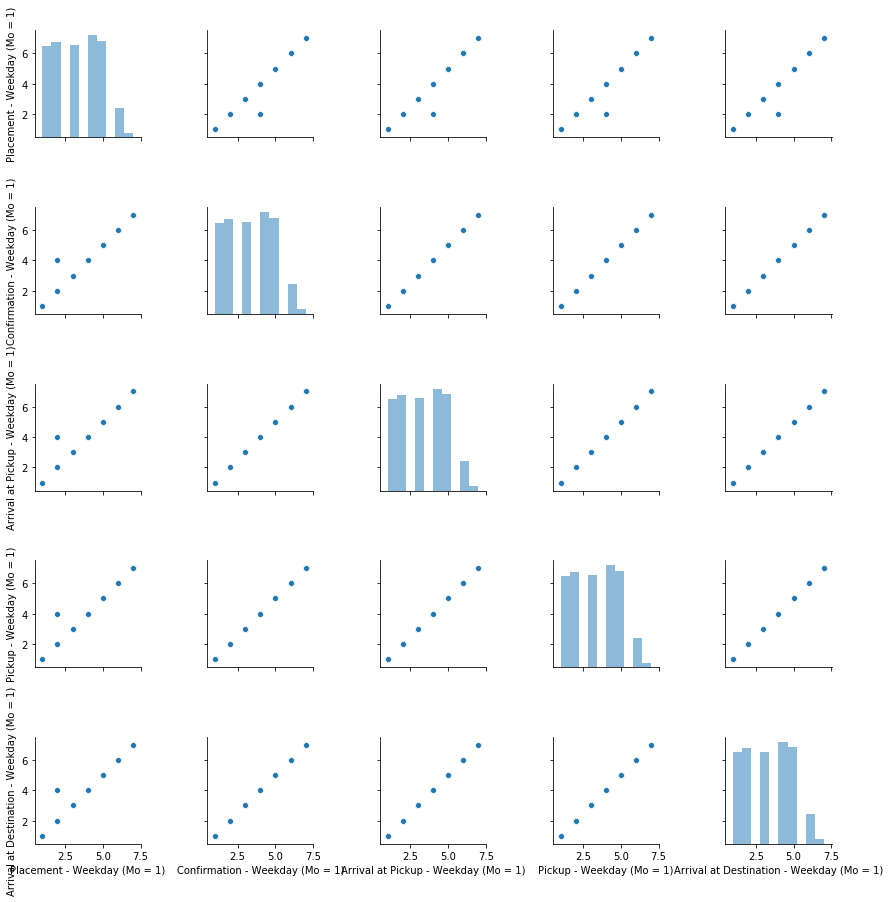

<Figure size 432x288 with 0 Axes>

In [818]:
sns.pairplot(data=data_merge,
        vars=['Placement - Weekday (Mo = 1)', 'Confirmation - Weekday (Mo = 1)', 'Arrival at Pickup - Weekday (Mo = 1)', 'Pickup - Weekday (Mo = 1)', 'Arrival at Destination - Weekday (Mo = 1)'],
        kind='scatter',
        palette='RdBu',
        diag_kws={'alpha':.5})

plt.show()
plt.clf()

# Suggestion: 
Keep Pickup 'Day of Month' and 'Weekday columns', remove others because clear display of multicollinearity apparent.
Choose Pickup because it is the most directly-related to drop-off time.

In [819]:
#Remove unnecessary columns
data_merge.pop('Placement - Weekday (Mo = 1)')
data_merge.pop('Confirmation - Weekday (Mo = 1)')
data_merge.pop('Arrival at Pickup - Weekday (Mo = 1)')
data_merge.pop('Pickup - Weekday (Mo = 1)')
data_merge.pop('Placement - Day of Month')
data_merge.pop('Confirmation - Day of Month')
data_merge.pop('Arrival at Pickup - Day of Month')
data_merge.pop('Pickup - Day of Month')
data_merge.head()

,Order No,Platform Type,Placement - Time,Confirmation - Time,Arrival at Pickup - Time,Pickup - Time,Arrival at Destination - Day of Month,Arrival at Destination - Weekday (Mo = 1),Arrival at Destination - Time,Distance (KM),...,P - Pl,Dest - Pl,Arr P - Con,P - Con,Dest - Con,P - Arr P,Dest - Arr P,Dest - P,temp_adj,Time from Pickup to Arrival
0,Order_No_4211,3,1900-01-01 09:35:46,1900-01-01 09:40:10,1900-01-01 10:04:47,1900-01-01 10:27:30,9,5,1900-01-01 10:39:55,4,...,3104,3849,1477,2840,3585,1363,2108,745,20.400000,745
1,Order_No_25375,3,1900-01-01 11:16:16,1900-01-01 11:23:21,1900-01-01 11:40:22,1900-01-01 11:44:09,12,5,1900-01-01 12:17:22,16,...,1673,3666,1021,1248,3241,227,2220,1993,26.400000,1993
2,Order_No_1899,3,1900-01-01 12:39:25,1900-01-01 12:42:44,1900-01-01 12:49:34,1900-01-01 12:53:03,30,2,1900-01-01 13:00:38,3,...,818,1273,410,619,1074,209,664,455,23.515638,455
3,Order_No_9336,3,1900-01-01 09:25:34,1900-01-01 09:26:05,1900-01-01 09:37:56,1900-01-01 09:43:06,15,5,1900-01-01 10:05:27,9,...,1052,2393,711,1021,2362,310,1651,1341,19.200000,1341
4,Order_No_27883,1,1900-01-01 09:55:18,1900-01-01 09:56:18,1900-01-01 10:03:53,1900-01-01 10:05:23,13,1,1900-01-01 10:25:37,9,...,605,1819,455,545,1759,90,1304,1214,15.400000,1214


In [820]:
data_merge.head()

,Order No,Platform Type,Placement - Time,Confirmation - Time,Arrival at Pickup - Time,Pickup - Time,Arrival at Destination - Day of Month,Arrival at Destination - Weekday (Mo = 1),Arrival at Destination - Time,Distance (KM),...,P - Pl,Dest - Pl,Arr P - Con,P - Con,Dest - Con,P - Arr P,Dest - Arr P,Dest - P,temp_adj,Time from Pickup to Arrival
0,Order_No_4211,3,1900-01-01 09:35:46,1900-01-01 09:40:10,1900-01-01 10:04:47,1900-01-01 10:27:30,9,5,1900-01-01 10:39:55,4,...,3104,3849,1477,2840,3585,1363,2108,745,20.400000,745
1,Order_No_25375,3,1900-01-01 11:16:16,1900-01-01 11:23:21,1900-01-01 11:40:22,1900-01-01 11:44:09,12,5,1900-01-01 12:17:22,16,...,1673,3666,1021,1248,3241,227,2220,1993,26.400000,1993
2,Order_No_1899,3,1900-01-01 12:39:25,1900-01-01 12:42:44,1900-01-01 12:49:34,1900-01-01 12:53:03,30,2,1900-01-01 13:00:38,3,...,818,1273,410,619,1074,209,664,455,23.515638,455
3,Order_No_9336,3,1900-01-01 09:25:34,1900-01-01 09:26:05,1900-01-01 09:37:56,1900-01-01 09:43:06,15,5,1900-01-01 10:05:27,9,...,1052,2393,711,1021,2362,310,1651,1341,19.200000,1341
4,Order_No_27883,1,1900-01-01 09:55:18,1900-01-01 09:56:18,1900-01-01 10:03:53,1900-01-01 10:05:23,13,1,1900-01-01 10:25:37,9,...,605,1819,455,545,1759,90,1304,1214,15.400000,1214


# Dealing with target vaue (Time from Pickup to Arrival)
1. Take into account outliers, how to deal with them
    1.1 Considered only the shortest times in the dataset, for longest times it's not possible to know whether there were any influencing factors such as traffic
    1.2 Calculate the spped the driver must have been going and evaluate from there (s = d/t)

In [ ]:
#Distribution of target value

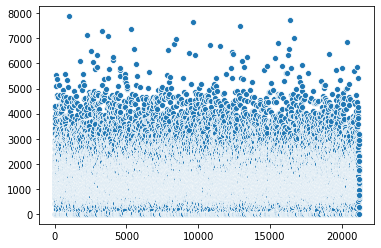

In [821]:
sns.scatterplot(data=data_merge['Time from Pickup to Arrival'])

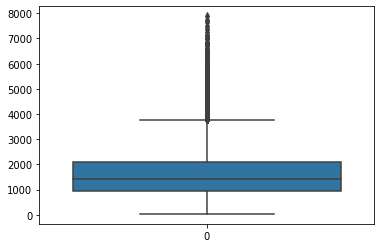

In [835]:
sns.boxplot(data=data_merge['Time from Pickup to Arrival'])

In [833]:
speed = data_merge.loc[:, ['Time from Pickup to Arrival', 'Distance (KM)']]
speed['speed (km/h)'] = 0 #speed['Distance (KM)'] / (speed['Time from Pickup to Destination'] / 3600)
for i in range(len(speed)):
    speed.iloc[i, 2] = speed.iloc[i, 1] / (speed.iloc[i, 0] / 3600)

data_merge['speed (km/h)'] = speed['speed (km/h)']
data_merge['speed (km/h)'].head()

Order No
Order_No_4211     19.328859
Order_No_25375    28.901154
Order_No_1899     23.736264
Order_No_9336     24.161074
Order_No_27883    26.688633
Name: speed (km/h), dtype: float64

In [834]:
#Drop rows that have speeds in excess of 110 km/h (max driving speed between Uganda and Kenya)
data_merge = data_merge.drop(data_merge[data_merge['speed (km/h)'] > 110].index)
print(len(data_merge)) #6 rows dropped

20301


# Split the training set into training and validation set
(enable us to evaluate our model because we don't have the ground truths of the test set)

In [28]:
#Create the matrix of features.
X = data_merge.iloc[:, :-1].values #numpy array
y = dataset.iloc[:, -1].values #numpy array

[['Order_No_4211' 'User_Id_633' 'Bike' ... 1309 13.8 549]
 ['Order_No_25375' 'User_Id_2285' 'Bike' ... 339 13.6 69]
 ['Order_No_1899' 'User_Id_265' 'Bike' ... 242 12.5 114]
 ...
 ['Order_No_2831' 'User_Id_2956' 'Bike' ... 473 13.8 29]
 ['Order_No_6174' 'User_Id_2524' 'Bike' ... 1821 14.0 1101]
 ['Order_No_9836' 'User_Id_718' 'Bike' ... 286 13.6 70]]


In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

NameError: name 'y' is not defined

# Missing data

# Encode categorical data
(Check dummy variable trap, only include n-1 dummy variables for every case where a dummy variable is necessary)

# Check assumptions of linear regression:
1. Linearity
2. Homoscedasticity
3. Multivariate normality
4. Independence of errors
5. Lack of multicolinearity

# Evaluation
Predicting the test set results
1. Plot predicted times from pick up to arrival
2. Select model with minimum mean square error in the test dataset